# Purpose of the Code

The goal of this notebook is to extract the Maximum Voluntary Contraction (MVC) value from EMG signal recorded from a specific muscle using Trigno system. The code processes the raw EMG data, identifies the segment corresponding to the peak muscle activation, and computes the maximum amplitude.

## Environment Setup

In [47]:
import os
import pandas as pd
import numpy as np
import sys
sys.path.append('../../lib')
from import_file import import_data_from_trigno
from trigno_utils import trigno_dataframe_edit, trigno_extract_muscle_emg
from emg_utils import plot_emg_signal, emg_filters, compute_MVC

In [119]:
# Parameters
subj = "10"
date = "_test"
muscle_names = ["biceps", "triceps"]  # Target muscle: "biceps" or "triceps" ("forearm1", "forearm2")
smooth_threshold_trigno = 0.005 # Max smoothness allowed for Trigno signal normalization
lenght = 28 # n° of "interesting" columns of CSV file

fs_list = []  # Initialize list to store sampling frequencies
mvc_dict = {}

# Paths for input and output
input_folder = f'../../data/acquisitions/trigno/{date}/S{subj}/_mvc'  # Input folder with raw data
full_path = os.path.join(f'../../data/mvc_values/trigno/{date}/', f'S{subj}.csv') # output folder and file name

# Load Data Files

In [120]:
dataframes = import_data_from_trigno(input_folder, lenght)
dataframes = [trigno_dataframe_edit(df) for df in dataframes]

In [121]:
muscle_emg_raw, emg_time = trigno_extract_muscle_emg(dataframes, muscle_names) # Extract EMG signals and timestamps for the specified muscle

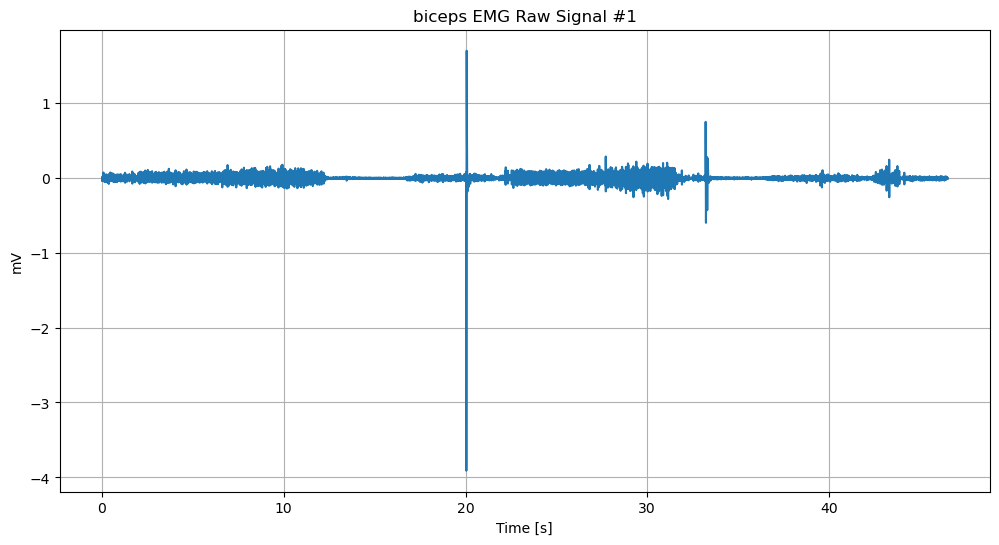

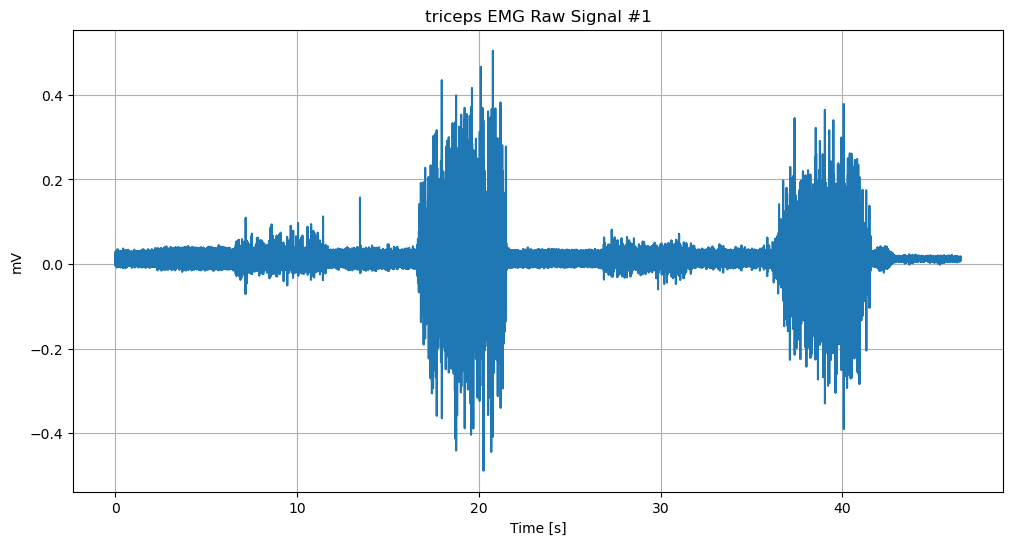

In [122]:
for muscle in muscle_names:
    plot_emg_signal(muscle_emg_raw[muscle][0], emg_time[0], title=f"{muscle} EMG Raw Signal #1")  # Plot raw EMG signal

# EMG Signal Analysis

In [123]:
for time in emg_time:
    fs = 1.0 / np.mean(np.diff(time))  # Calculate sampling frequency from time intervals
    fs_list.append(fs)  

In [124]:
_, _, muscle_emg_smoothed = emg_filters(muscle_emg_raw, emg_time, fs_list)  # Filter EMG signals

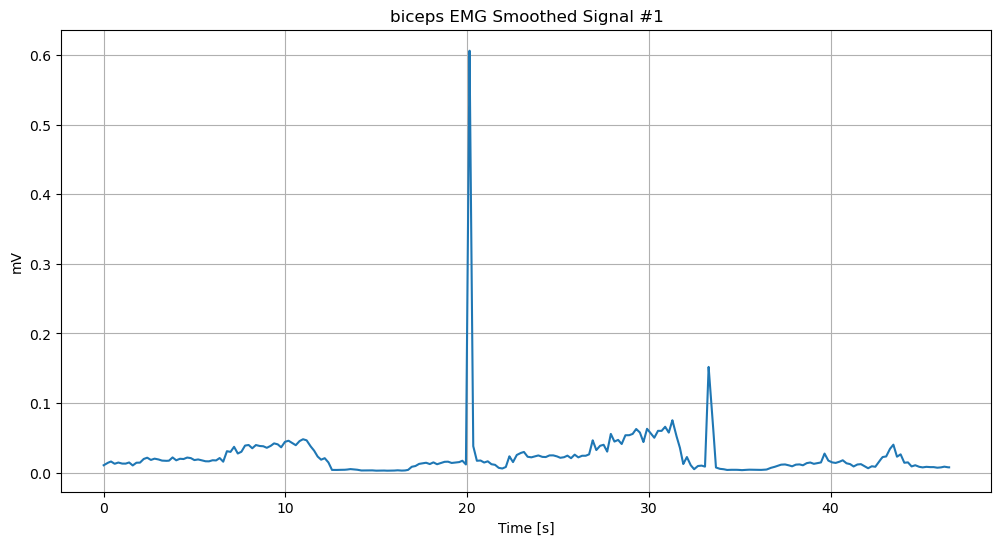

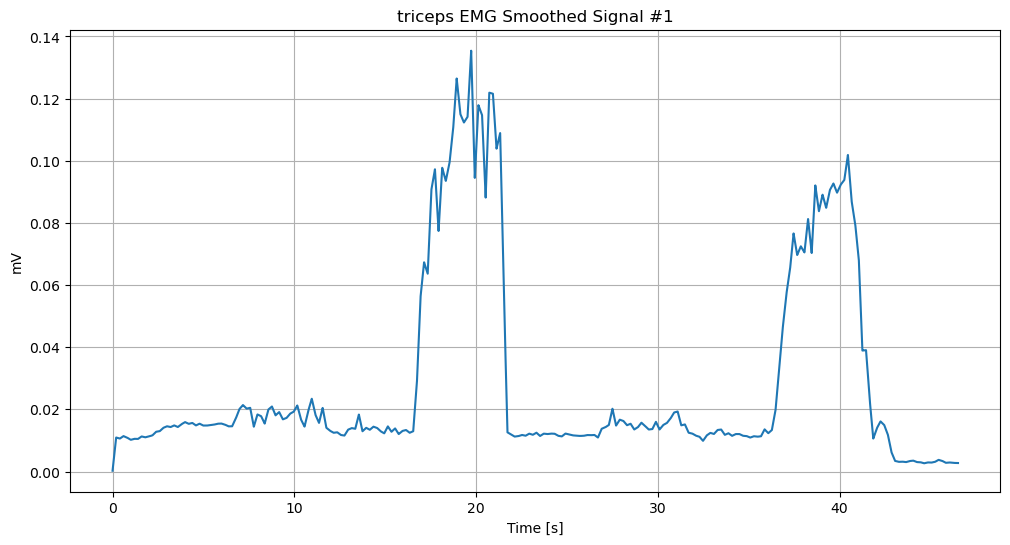

In [125]:
for muscle in muscle_names:
    plot_emg_signal(muscle_emg_smoothed[muscle][0], emg_time[0], 
                    title=f"{muscle} EMG Smoothed Signal #1")  # Plot smoothed EMG signal

# Compute MVC

In [126]:
for muscle in muscle_names:
    signal = muscle_emg_smoothed[muscle][0]
    mvc = compute_MVC(signal, fs, window=2, smooth_threshold=smooth_threshold_trigno)
    #mvc = max(signal)
    mvc_dict[muscle] = mvc

# Export MVC

In [127]:
mvc_df = pd.DataFrame.from_dict(mvc_dict, orient='index', columns=['MVC'])
print(mvc_df)

              MVC
biceps   0.058584
triceps  0.112708


In [128]:
mvc_df.to_csv(full_path)